# 01 — Estatísticas Descritivas do Corpus (Cap. 6.1)

Distribuição dos 10 indicadores ordinais de purificação, score composto de endurecimento,
e análise por regime iconocrático, país, período e suporte.

**Fonte:** `data/processed/corpus_dataset.csv` (95 itens, 100% codificados)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from math import pi

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 120

df = pd.read_csv('../data/processed/corpus_dataset.csv')

INDICATORS = ['desincorporacao', 'rigidez_postural', 'dessexualizacao',
              'uniformizacao_facial', 'heraldizacao', 'enquadramento_arquitetonico',
              'apagamento_narrativo', 'monocromatizacao', 'serialidade', 'inscricao_estatal']

INDICATOR_LABELS = {
    'desincorporacao': 'Desincorporação', 'rigidez_postural': 'Rigidez postural',
    'dessexualizacao': 'Dessexualização', 'uniformizacao_facial': 'Uniformização facial',
    'heraldizacao': 'Heraldicização', 'enquadramento_arquitetonico': 'Enquadramento arq.',
    'apagamento_narrativo': 'Apagamento narrativo', 'monocromatizacao': 'Monocromatização',
    'serialidade': 'Serialidade', 'inscricao_estatal': 'Inscrição estatal',
}
regime_order = ['fundacional', 'normativo', 'militar']

print(f"Corpus: {len(df)} itens, {df['purificacao_composto'].notna().sum()} codificados")
print(f"endurecimento — min: {df.purificacao_composto.min():.2f}, max: {df.purificacao_composto.max():.2f}, média: {df.purificacao_composto.mean():.2f}")
print(f"Regimes: {df.regime_iconocratico.value_counts().to_dict()}")
print(f"Países (top 6): {df.country.value_counts().head(6).to_dict()}")

Corpus: 145 itens, 145 codificados
endurecimento — min: 0.10, max: 3.10, média: 1.44
Regimes: {'fundacional': 71, 'normativo': 40, 'militar': 27, 'contra-alegoria': 7}
Países (top 6): {'France': 42, 'United States': 20, 'Germany': 18, 'Brazil': 12, 'United Kingdom': 10, 'Italy': 8}


## 1.1 Distribuição do score composto de endurecimento

/var/folders/_j/9nc46yj159z2zkp8jhff7rj40000gn/T/ipykernel_35268/2895044736.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='regime_iconocratico', y='purificacao_composto', order=regime_order, palette=palette, ax=axes[1])


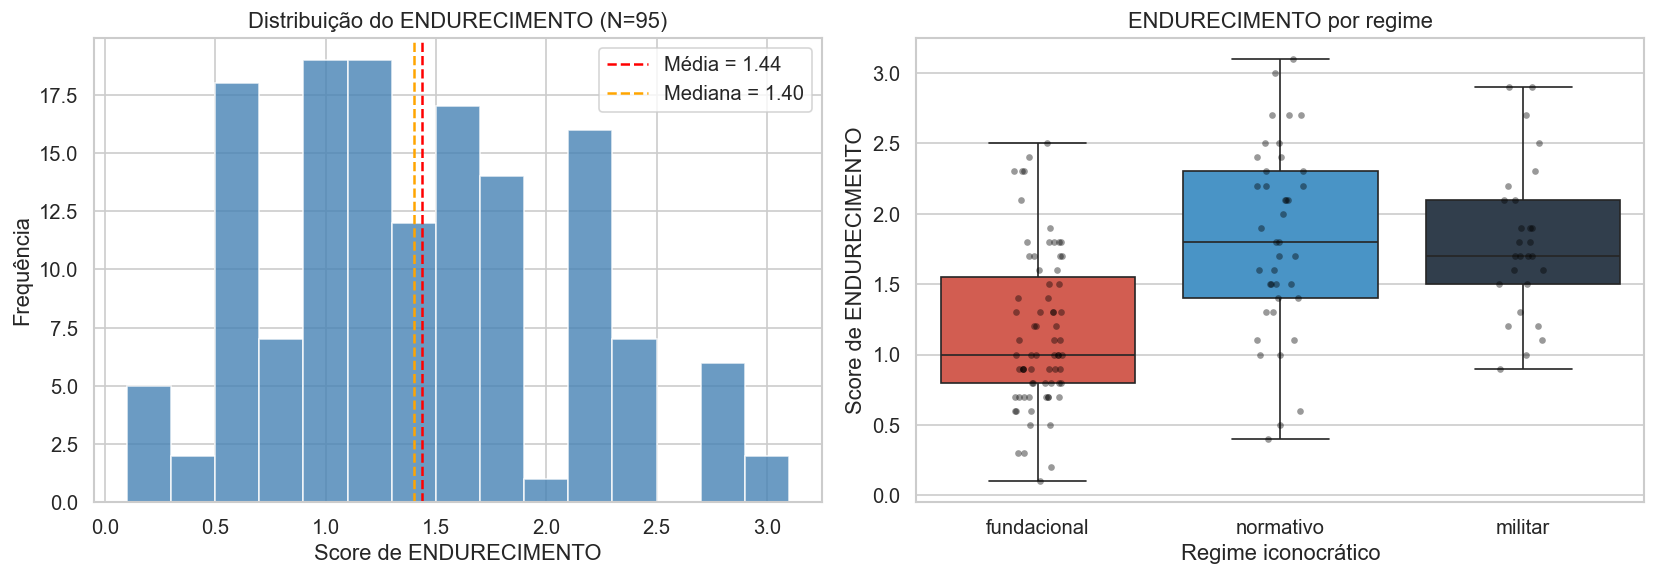

                     count  mean   std  min   25%  50%   75%  max
regime_iconocratico                                              
contra-alegoria        7.0  0.71  0.47  0.3  0.45  0.6  0.75  1.7
fundacional           71.0  1.16  0.55  0.1  0.80  1.0  1.55  2.5
militar               27.0  1.80  0.54  0.9  1.50  1.7  2.10  2.9
normativo             40.0  1.82  0.66  0.4  1.40  1.8  2.30  3.1


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df['purificacao_composto'], bins=15, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(df['purificacao_composto'].mean(), color='red', ls='--', label=f"Média = {df.purificacao_composto.mean():.2f}")
axes[0].axvline(df['purificacao_composto'].median(), color='orange', ls='--', label=f"Mediana = {df.purificacao_composto.median():.2f}")
axes[0].set_xlabel('Score de endurecimento')
axes[0].set_ylabel('Frequência')
axes[0].set_title('Distribuição do endurecimento (N=95)')
axes[0].legend()

palette = {'fundacional': '#e74c3c', 'normativo': '#3498db', 'militar': '#2c3e50'}
sns.boxplot(data=df, x='regime_iconocratico', y='purificacao_composto', order=regime_order, palette=palette, ax=axes[1])
sns.stripplot(data=df, x='regime_iconocratico', y='purificacao_composto', order=regime_order, color='black', alpha=0.4, size=4, ax=axes[1])
axes[1].set_xlabel('Regime iconocrático')
axes[1].set_ylabel('Score de endurecimento')
axes[1].set_title('endurecimento por regime')

plt.tight_layout()
plt.savefig('../data/processed/fig_01_endurecimento_dist.png', dpi=150, bbox_inches='tight')
plt.show()
print(df.groupby('regime_iconocratico')['purificacao_composto'].describe().round(2))

## 1.2 Heatmap: 10 indicadores por regime

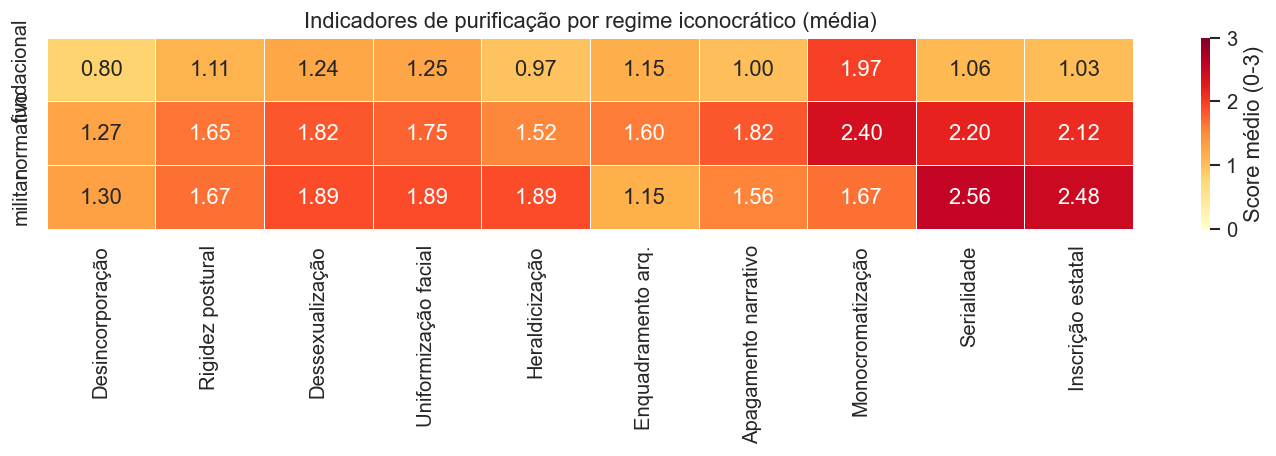

In [3]:
means = df.groupby('regime_iconocratico')[INDICATORS].mean().reindex(regime_order)
means.columns = [INDICATOR_LABELS[c] for c in means.columns]
fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(means, annot=True, fmt='.2f', cmap='YlOrRd', vmin=0, vmax=3, linewidths=0.5, ax=ax, cbar_kws={'label': 'Score médio (0-3)'})
ax.set_title('Indicadores de purificação por regime iconocrático (média)')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('../data/processed/fig_02_heatmap_regime.png', dpi=150, bbox_inches='tight')
plt.show()

## 1.3 Radar plot: perfil morfológico por regime

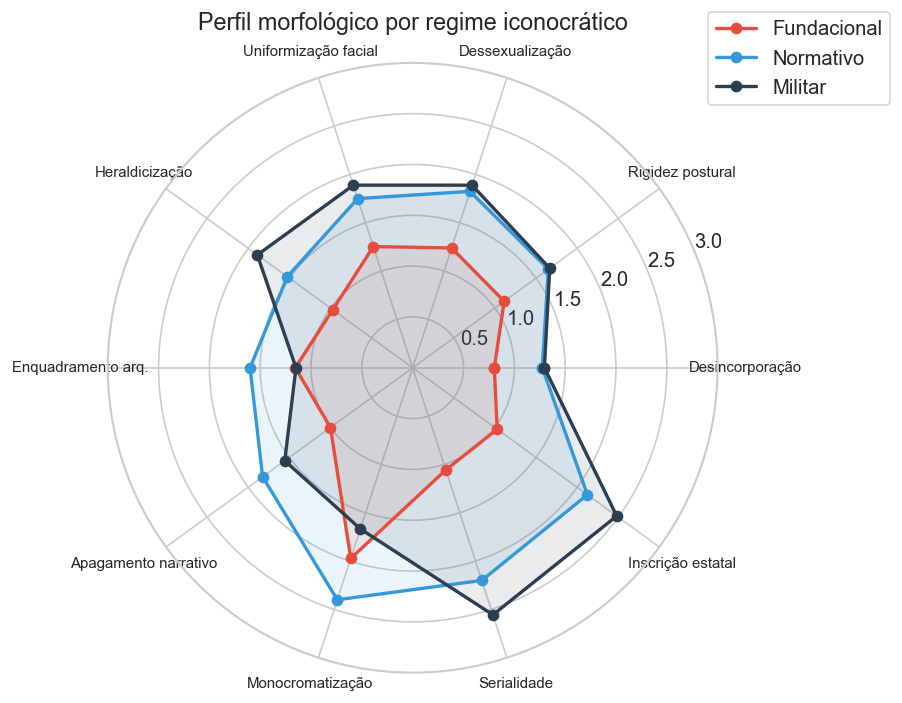

In [4]:
categories = [INDICATOR_LABELS[i] for i in INDICATORS]
N_cat = len(categories)
angles = [n / float(N_cat) * 2 * pi for n in range(N_cat)]
angles += angles[:1]
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colors = {'fundacional': '#e74c3c', 'normativo': '#3498db', 'militar': '#2c3e50'}
for regime in regime_order:
    values = df[df.regime_iconocratico == regime][INDICATORS].mean().values.tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=regime.capitalize(), color=colors[regime])
    ax.fill(angles, values, alpha=0.1, color=colors[regime])
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=9)
ax.set_ylim(0, 3)
ax.set_title('Perfil morfológico por regime iconocrático', size=14, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.savefig('../data/processed/fig_03_radar_regime.png', dpi=150, bbox_inches='tight')
plt.show()

## 1.4 endurecimento por país e por suporte

/var/folders/_j/9nc46yj159z2zkp8jhff7rj40000gn/T/ipykernel_35268/4108060017.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top, y='country', x='purificacao_composto', order=country_order, palette='coolwarm', ax=axes[0])
/var/folders/_j/9nc46yj159z2zkp8jhff7rj40000gn/T/ipykernel_35268/4108060017.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_media, y='medium_norm', x='purificacao_composto', order=media_order, palette='viridis', ax=axes[1])


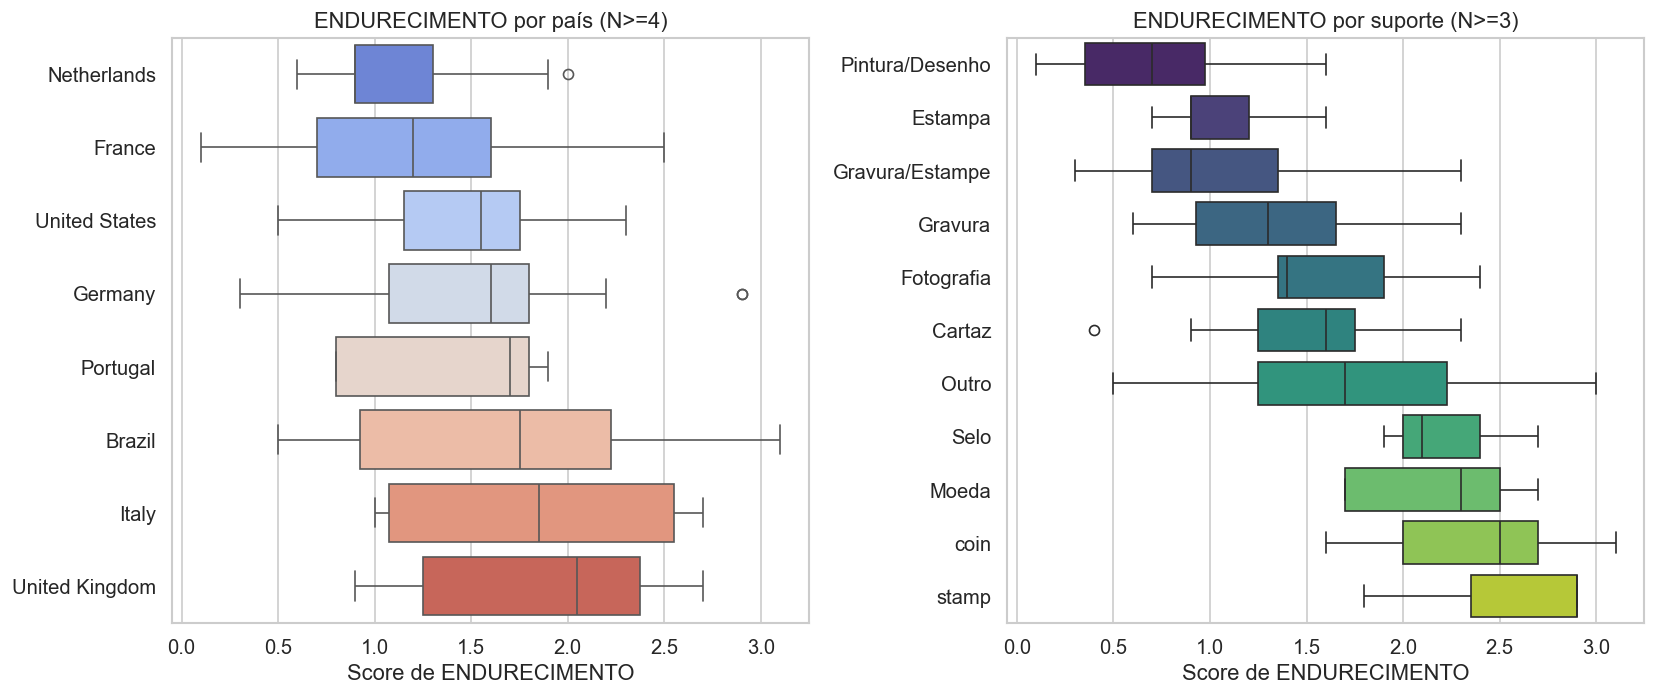

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
top_countries = df.country.value_counts().head(8).index.tolist()
df_top = df[df.country.isin(top_countries)]
country_order = df_top.groupby('country')['purificacao_composto'].median().sort_values().index.tolist()
sns.boxplot(data=df_top, y='country', x='purificacao_composto', order=country_order, palette='coolwarm', ax=axes[0])
axes[0].set_xlabel('Score de endurecimento')
axes[0].set_ylabel('')
axes[0].set_title('endurecimento por país (N>=4)')

medium_counts = df.medium_norm.value_counts()
top_media = medium_counts[medium_counts >= 3].index.tolist()
df_media = df[df.medium_norm.isin(top_media)]
media_order = df_media.groupby('medium_norm')['purificacao_composto'].median().sort_values().index.tolist()
sns.boxplot(data=df_media, y='medium_norm', x='purificacao_composto', order=media_order, palette='viridis', ax=axes[1])
axes[1].set_xlabel('Score de endurecimento')
axes[1].set_ylabel('')
axes[1].set_title('endurecimento por suporte (N>=3)')

plt.tight_layout()
plt.savefig('../data/processed/fig_04_country_medium.png', dpi=150, bbox_inches='tight')
plt.show()

## 1.5 Correlação entre indicadores (Spearman)

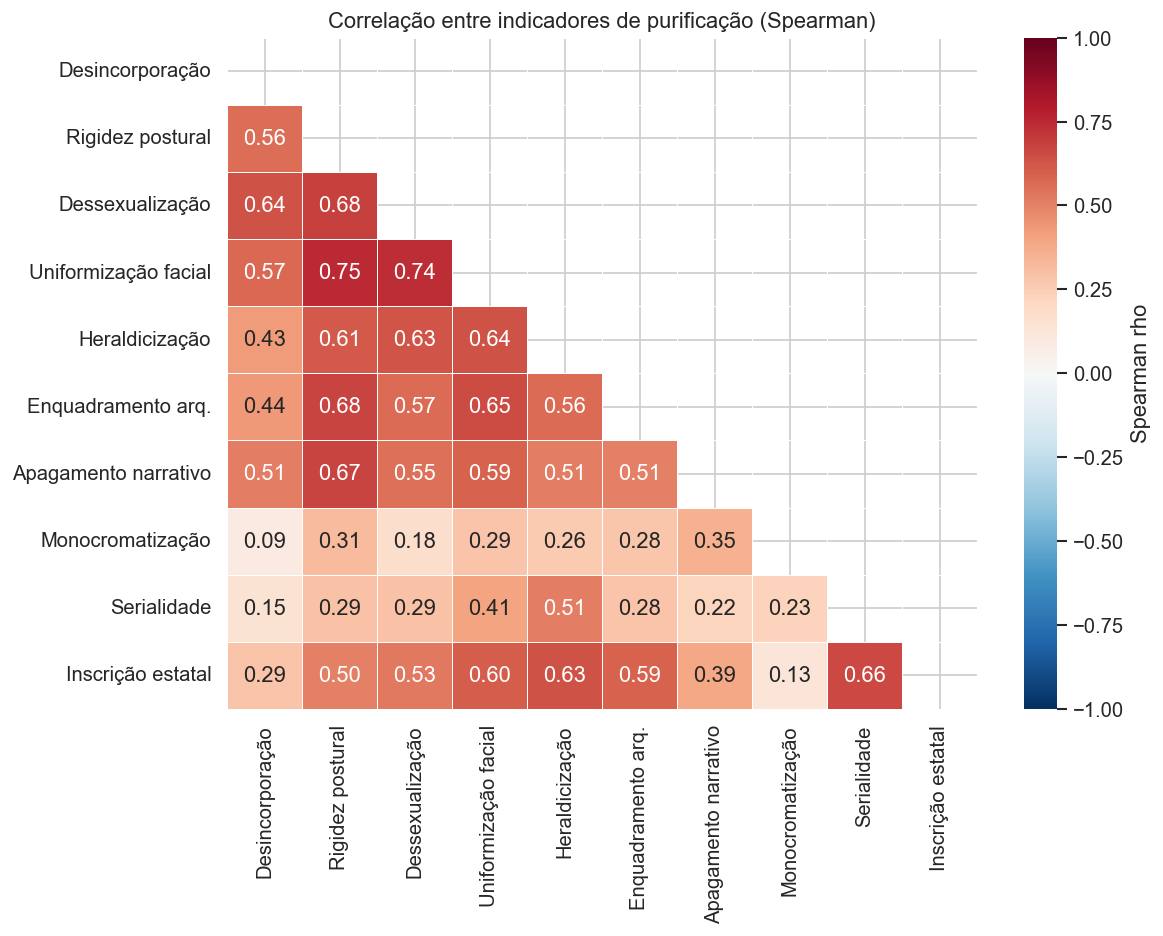

Top 5 correlações:
  Rigidez postural x Uniformização facial: rho = 0.750
  Dessexualização x Uniformização facial: rho = 0.738
  Rigidez postural x Dessexualização: rho = 0.681
  Rigidez postural x Enquadramento arq.: rho = 0.678
  Rigidez postural x Apagamento narrativo: rho = 0.673


In [6]:
corr = df[INDICATORS].corr(method='spearman')
corr.columns = [INDICATOR_LABELS[c] for c in corr.columns]
corr.index = [INDICATOR_LABELS[c] for c in corr.index]
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax, cbar_kws={'label': 'Spearman rho'})
ax.set_title('Correlação entre indicadores de purificação (Spearman)')
plt.tight_layout()
plt.savefig('../data/processed/fig_05_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
pairs = []
for i, c1 in enumerate(INDICATORS):
    for j, c2 in enumerate(INDICATORS):
        if i < j:
            r = df[INDICATORS].corr(method='spearman').loc[c1, c2]
            pairs.append((INDICATOR_LABELS[c1], INDICATOR_LABELS[c2], r))
pairs.sort(key=lambda x: abs(x[2]), reverse=True)
print("Top 5 correlações:")
for a, b, r in pairs[:5]:
    print(f"  {a} x {b}: rho = {r:.3f}")